In [2]:
from google.colab import files

uploaded = files.upload()

Saving CO2 Emissions-selected-columns.csv to CO2 Emissions-selected-columns (1).csv


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv(next(iter(uploaded)))

df.head()

,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km)
0,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5
1,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6
2,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9
3,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1
4,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6


In [5]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 7385
Columns: 10


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7385 entries, 0 to 7384
Data columns (total 10 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Make                              7385 non-null   object 
 1   Model                             7385 non-null   object 
 2   Vehicle Class                     7385 non-null   object 
 3   Engine Size(L)                    7385 non-null   float64
 4   Cylinders                         7385 non-null   int64  
 5   Transmission                      7385 non-null   object 
 6   Fuel Type                         7385 non-null   object 
 7   Fuel Consumption City (L/100 km)  7385 non-null   float64
 8   Fuel Consumption Hwy (L/100 km)   7385 non-null   float64
 9   Fuel Consumption Comb (L/100 km)  7385 non-null   float64
dtypes: float64(4), int64(1), object(5)
memory usage: 577.1+ KB


In [7]:
df.describe()

,Engine Size(L),Cylinders,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km)
count,7385.000000,7385.000000,7385.000000,7385.000000,7385.000000
mean,3.160068,5.615030,12.556534,9.041706,10.975071
std,1.354170,1.828307,3.500274,2.224456,2.892506
min,0.900000,3.000000,4.200000,4.000000,4.100000
25%,2.000000,4.000000,10.100000,7.500000,8.900000
50%,3.000000,6.000000,12.100000,8.700000,10.600000
75%,3.700000,6.000000,14.600000,10.200000,12.600000
max,8.400000,16.000000,30.600000,20.600000,26.100000


In [8]:
print(df.isnull().sum())

Make                                0
Model                               0
Vehicle Class                       0
Engine Size(L)                      0
Cylinders                           0
Transmission                        0
Fuel Type                           0
Fuel Consumption City (L/100 km)    0
Fuel Consumption Hwy (L/100 km)     0
Fuel Consumption Comb (L/100 km)    0
dtype: int64


In [10]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 1702


In [11]:
df = df.drop_duplicates()

In [12]:
print(df.columns.tolist())

['Make', 'Model', 'Vehicle Class', 'Engine Size(L)', 'Cylinders', 'Transmission', 'Fuel Type', 'Fuel Consumption City (L/100 km)', 'Fuel Consumption Hwy (L/100 km)', 'Fuel Consumption Comb (L/100 km)']


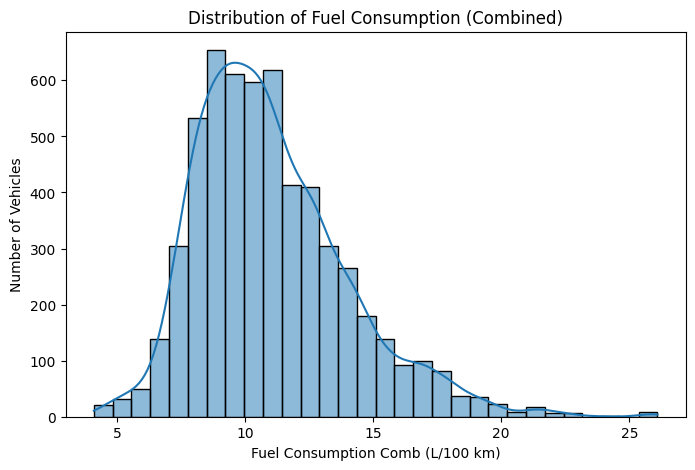

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

# The target variable is already defined in the environment as 'CO2 Emissions(g/km)'
# target = 'CO2 Emissions(g/km)'

plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x='Fuel Consumption Comb (L/100 km)', # Corrected column name
    bins=30,
    kde=True
)

plt.title('Distribution of Fuel Consumption (Combined)')
plt.xlabel('Fuel Consumption Comb (L/100 km)')
plt.ylabel('Number of Vehicles')
plt.show()

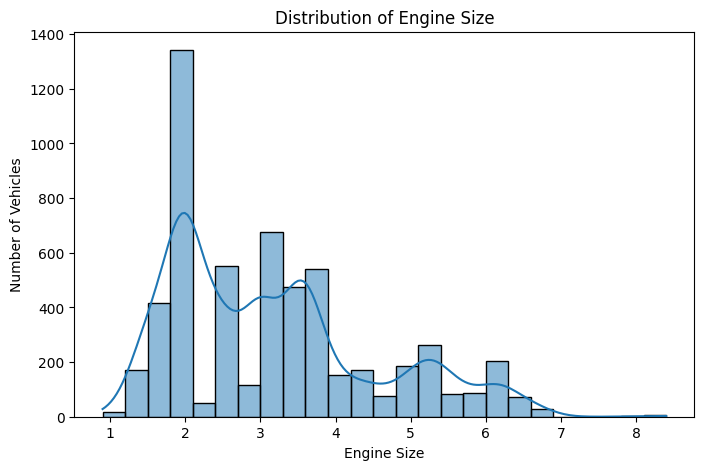

In [31]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x='Engine Size(L)', # Corrected column name
    bins=25,
    kde=True
)

plt.title('Distribution of Engine Size')
plt.xlabel('Engine Size')
plt.ylabel('Number of Vehicles')
plt.show()

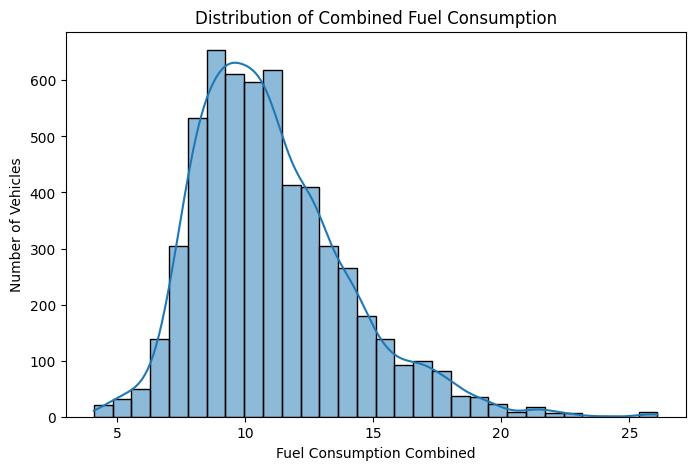

In [32]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x='Fuel Consumption Comb (L/100 km)', # Corrected column name
    bins=30,
    kde=True
)

plt.title('Distribution of Combined Fuel Consumption')
plt.xlabel('Fuel Consumption Combined')
plt.ylabel('Number of Vehicles')
plt.show()

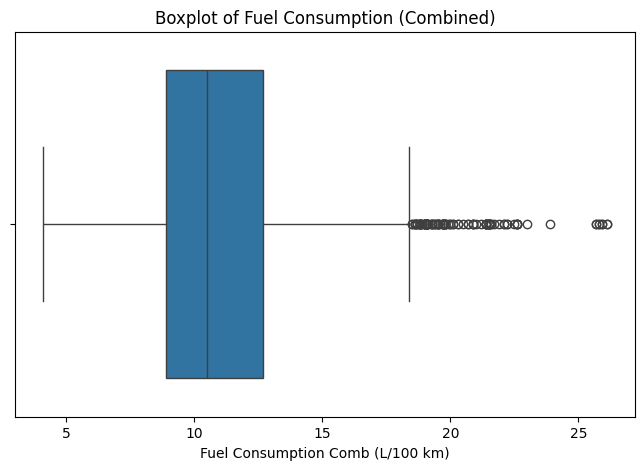

In [34]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='Fuel Consumption Comb (L/100 km)' # Corrected column name
)

plt.title('Boxplot of Fuel Consumption (Combined)')
plt.xlabel('Fuel Consumption Comb (L/100 km)')
plt.show()

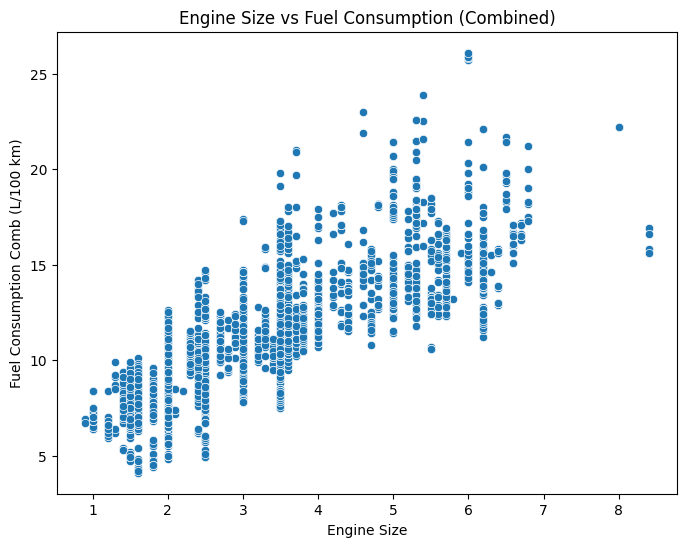

In [36]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='Engine Size(L)',
    y='Fuel Consumption Comb (L/100 km)' # Corrected column name
)

plt.title('Engine Size vs Fuel Consumption (Combined)')
plt.xlabel('Engine Size')
plt.ylabel('Fuel Consumption Comb (L/100 km)')
plt.show()

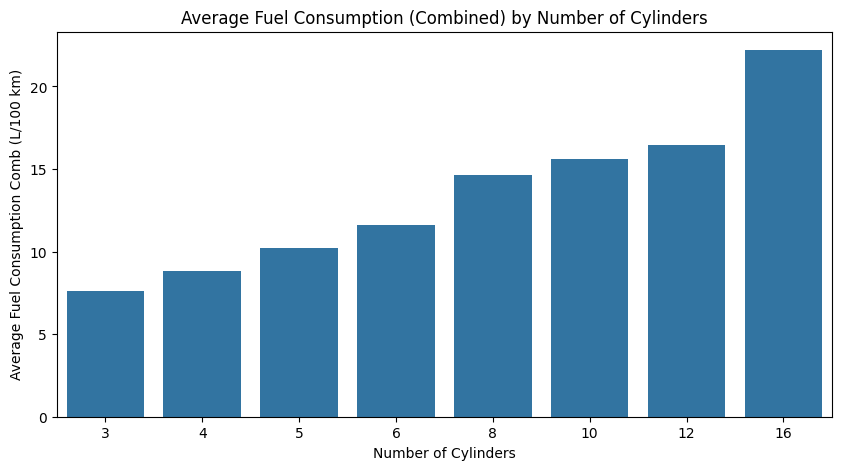

In [38]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=df,
    x='Cylinders',
    y='Fuel Consumption Comb (L/100 km)', # Corrected column name
    errorbar=None
)

plt.title('Average Fuel Consumption (Combined) by Number of Cylinders')
plt.xlabel('Number of Cylinders')
plt.ylabel('Average Fuel Consumption Comb (L/100 km)')
plt.show()

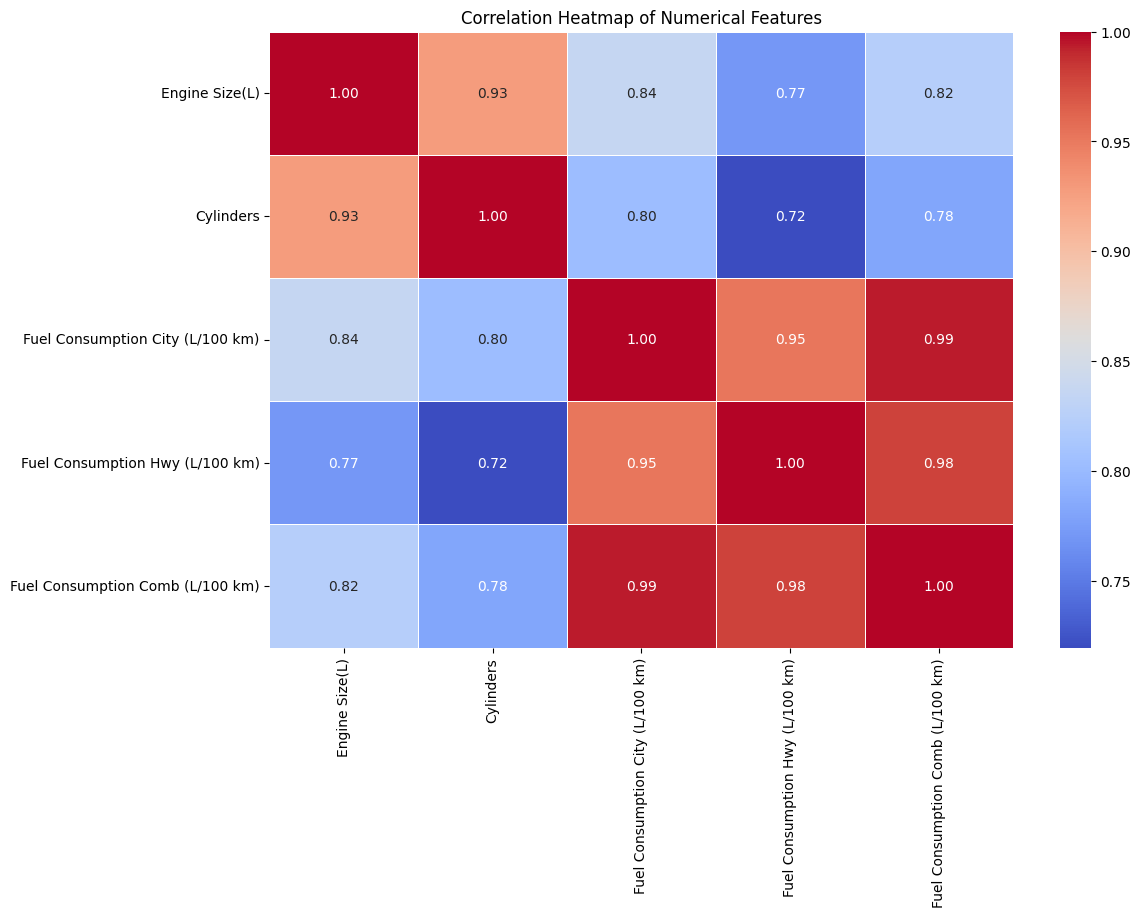

In [39]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(12,8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5
)

plt.title('Correlation Heatmap of Numerical Features')
plt.show()

In [41]:
model_df = df[
    [
        'Engine Size(L)',
        'Cylinders',
        'Fuel Type',
        'Fuel Consumption Comb (L/100 km)' # Corrected column name
    ]
].copy()

model_df.head()

,Engine Size(L),Cylinders,Fuel Type,Fuel Consumption Comb (L/100 km)
0,2.0,4,Z,8.5
1,2.4,4,Z,9.6
2,1.5,4,Z,5.9
3,3.5,6,Z,11.1
4,3.5,6,Z,10.6


In [43]:
X = model_df.drop(columns=['Fuel Consumption Comb (L/100 km)'])
y = model_df['Fuel Consumption Comb (L/100 km)']

In [45]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (4546, 3)
Testing data: (1137, 3)


In [53]:
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R2  :", r2)

MAE : 1.0140579936730072
MSE : 1.8594041184776158
RMSE: 1.363599691433529
R2  : 0.8010494971449704


In [54]:
co2_results = pd.DataFrame({
    'Metric': ['MAE', 'MSE', 'RMSE', 'R2 Score'],
    'Value': [mae, mse, rmse, r2]
})

co2_results

,Metric,Value
0,MAE,1.014058
1,MSE,1.859404
2,RMSE,1.363600
3,R2 Score,0.801049
